In [2]:
# ## 1. Setup and Data Loading

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# %%
# Connect to SQLite databases
def get_db_connection(city):
    """Get SQLite connection for a city."""
    db_path = f'../data/processed/{city}/{city}.db'
    return sqlite3.connect(db_path)

# Helper function to query
def query_db(conn, query):
    """Run query and return DataFrame."""
    return pd.read_sql_query(query, conn)

# Connect to all cities
nyc_conn = get_db_connection('nyc')
bcn_conn = get_db_connection('barcelona')
edi_conn = get_db_connection('edinburgh')

print("✅ Connected to all SQLite databases")


✅ Connected to all SQLite databases


In [3]:
## 2. Data Validation - Check Tables

def list_tables(conn, city_name):
    """List all tables in the database."""
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
    tables = cursor.fetchall()
    print(f"\n📁 {city_name} Tables:")
    for table in tables:
        count = pd.read_sql_query(f"SELECT COUNT(*) as count FROM {table[0]}", conn)
        print(f"  {table[0]}: {count.iloc[0,0]:,} rows")

list_tables(nyc_conn, 'NYC')
list_tables(bcn_conn, 'Barcelona')
list_tables(edi_conn, 'Edinburgh')



📁 NYC Tables:
  listings: 35,036 rows
  calendar: 100,000 rows
  calendar_stats: 274 rows
  reviews: 1,003,299 rows
  neighbourhoods: 230 rows
  dim_listing: 35,036 rows
  dim_host: 21,048 rows
  dim_neighbourhood: 5 rows
  dim_date: 366 rows
  fact_listing_summary: 35,036 rows
  fact_reviews: 1,003,299 rows

📁 Barcelona Tables:
  listings: 18,177 rows
  calendar: 100,000 rows
  calendar_stats: 274 rows
  reviews: 991,795 rows
  neighbourhoods: 73 rows
  dim_listing: 18,177 rows
  dim_host: 5,776 rows
  dim_neighbourhood: 10 rows
  dim_date: 366 rows
  fact_listing_daily: 0 rows
  fact_listing_summary: 18,177 rows
  fact_reviews: 991,795 rows

📁 Edinburgh Tables:
  listings: 4,936 rows
  calendar: 100,000 rows
  calendar_stats: 274 rows
  reviews: 559,087 rows
  neighbourhoods: 111 rows
  dim_listing: 4,936 rows
  dim_host: 3,037 rows
  dim_neighbourhood: 2 rows
  dim_date: 365 rows
  fact_listing_daily: 0 rows
  fact_listing_summary: 4,936 rows
  fact_reviews: 559,087 rows



NYC columns: ['listing_key', 'host_key', 'neighbourhood_key', 'price', 'room_type', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'price_per_bedroom', 'host_tenure_years', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'host_is_superhost', 'estimated_occupancy_rate', 'estimated_annual_revenue']
✅ NYC: 20,191 rows loaded

Barcelona columns: ['listing_key', 'host_key', 'neighbourhood_key', 'price', 'room_type', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'price_per_bedroom', 'host_tenure_years', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_

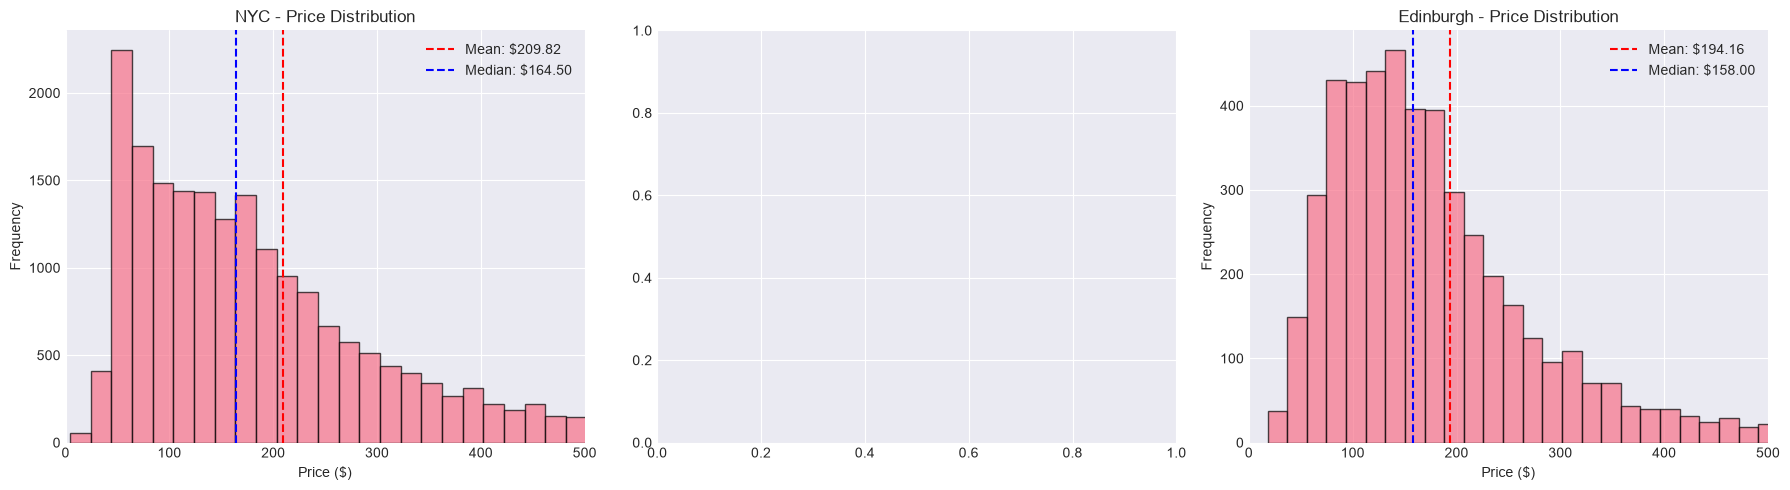

In [4]:
## 3. Price Distribution Analysis

# Get price data for all cities
price_data = []
for conn, city in [(nyc_conn, 'NYC'), (bcn_conn, 'Barcelona'), (edi_conn, 'Edinburgh')]:
    try:
        # Check what columns exist in fact_listing_summary
        check_query = "PRAGMA table_info(fact_listing_summary)"
        columns = pd.read_sql_query(check_query, conn)
        print(f"\n{city} columns:", columns['name'].tolist())
        
        # Build query with available columns
        select_cols = ["price", "number_of_reviews", "review_scores_rating"]
        
        # Check if room_type exists
        if 'room_type' in columns['name'].values:
            select_cols.append("room_type")
        else:
            # Try alternative column names
            try:
                # Try to get room_type from dim_listing if available
                alt_query = """
                SELECT 
                    fs.price,
                    fs.number_of_reviews,
                    fs.review_scores_rating,
                    dl.room_type
                FROM fact_listing_summary fs
                LEFT JOIN dim_listing dl ON fs.listing_key = dl.listing_key
                WHERE fs.price IS NOT NULL AND fs.price < 1000
                """
                df = pd.read_sql_query(alt_query, conn)
                df['city'] = city
                price_data.append(df)
                print(f"✅ {city}: Used dim_listing for room_type")
                continue
            except:
                select_cols.append("NULL AS room_type")
        
        # Build main query
        query = f"""
            SELECT 
                {', '.join(select_cols)}
            FROM fact_listing_summary
            WHERE price IS NOT NULL AND price < 1000
        """
        
        df = pd.read_sql_query(query, conn)
        df['city'] = city
        price_data.append(df)
        print(f"✅ {city}: {len(df):,} rows loaded")
        
    except Exception as e:
        print(f"❌ Could not query {city}: {e}")

# %%
# Combine data
if price_data:
    price_df = pd.concat(price_data, ignore_index=True)
    print(f"\nTotal listings analyzed: {len(price_df):,}")
else:
    print("No price data found. Please run the pipeline first.")
    # Create empty dataframe to avoid NameError
    price_df = pd.DataFrame()

# %%
# Price distribution by city
if len(price_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, city in enumerate(['NYC', 'Barcelona', 'Edinburgh']):
        city_data = price_df[price_df.city == city]
        if len(city_data) > 0:
            axes[idx].hist(city_data['price'], bins=50, edgecolor='black', alpha=0.7)
            axes[idx].axvline(city_data['price'].mean(), color='red', linestyle='--', 
                              label=f'Mean: ${city_data["price"].mean():.2f}')
            axes[idx].axvline(city_data['price'].median(), color='blue', linestyle='--',
                              label=f'Median: ${city_data["price"].median():.2f}')
            axes[idx].set_title(f'{city} - Price Distribution')
            axes[idx].set_xlabel('Price ($)')
            axes[idx].set_ylabel('Frequency')
            axes[idx].legend()
            axes[idx].set_xlim(0, 500)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/price_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ No price data available to plot")